# Credit Risk Decision System for Smarter Loan Approvals
This project aims to predict the likelihood of loan default using borrower financial and credit history in order to support better lending decisions.

## Dataset Description
- emp_title: Job title.
- emp_length: Number of years in the job, rounded down. If longer than 10 years, then this is represented by the value 10.
- state: Two-letter state code.
- homeownership: The ownership status of the applicant's residence.
- annual_income: Annual income.
- verified_income: Type of verification of the applicant's income.
- debt_to_income: Debt-to-income ratio.
- annual_income_joint: If this is a joint application, then the annual income of the two parties applying.
- verification_income_joint: Type of verification of the joint income.
- debt_to_income_joint: Debt-to-income ratio for the two parties.
- delinq_2y: Delinquencies on lines of credit in the last 2 years.
- months_since_last_delinq: Months since the last delinquency.
- earliest_credit_line: Year of the applicant's earliest line of credit
- inquiries_last_12m: Inquiries into the applicant's credit during the last 12 months.
- total_credit_lines: Total number of credit lines in this applicant's credit history.
- open_credit_lines: Number of currently open lines of credit.
- total_credit_limit: Total available credit, e.g. if only credit cards, then the total of all the credit limits. This excludes a mortgage.
- total_credit_utilized: Total credit balance, excluding a mortgage.
- num_collections_last_12m: Number of collections in the last 12 months. This excludes medical collections.
- num_historical_failed_to_pay: The number of derogatory public records, which roughly means the number of times the applicant failed to pay.
- months_since_90d_late: Months since the last time the applicant was 90 days late on a payment.
- current_accounts_delinq: Number of accounts where the applicant is currently delinquent.
- total_collection_amount_ever: The total amount that the applicant has had against them in collections.
- current_installment_accounts: Number of installment accounts, which are (roughly) accounts with a fixed payment amount and period. A typical example might be a 36-month car loan.
- accounts_opened_24m: Number of new lines of credit opened in the last 24 months.
- months_since_last_credit_inquiry: Number of months since the last credit inquiry on this applicant.
- num_satisfactory_accounts: Number of satisfactory accounts.
- num_accounts_120d_past_due: Number of current accounts that are 120 days past due.
- num_accounts_30d_past_due: Number of current accounts that are 30 days past due.
- num_active_debit_accounts: Number of currently active bank cards.
- total_debit_limit: Total of all bank card limits.
- num_total_cc_accounts: Total number of credit card accounts in the applicant's history.
- num_open_cc_accounts: Total number of currently open credit card accounts.
- num_cc_carrying_balance: Number of credit cards that are carrying a balance.
- num_mort_accounts: Number of mortgage accounts.
- account_never_delinq_percent: Percent of all lines of credit where the applicant was never delinquent.
- tax_liens: a numeric vector
- public_record_bankrupt: Number of bankruptcies listed in the public record for this applicant.
- loan_purpose: The category for the purpose of the loan.
- application_type: The type of application: either individual or joint.
- loan_amount: The amount of the loan the applicant received.
- term: The number of months of the loan the applicant received.
- interest_rate: Interest rate of the loan the applicant received.
- installment: Monthly payment for the loan the applicant received.
- grade: Grade associated with the loan.
- sub_grade: Detailed grade associated with the loan.
- issue_month: Month the loan was issued.
- loan_status: Status of the loan.
- initial_listing_status: Initial listing status of the loan. (whether the lender provided the entire loan or if the loan is across multiple lenders.)
- disbursement_method: Dispersement method of the loan.
- balance: Current balance on the loan.
- paid_total: Total that has been paid on the loan by the applicant.
- paid_principal: The difference between the original loan amount and the current balance on the loan.
- paid_interest: The amount of interest paid so far by the applicant.
- paid_late_fees: Late fees paid by the applicant.

## Files
Data has been collected and stored as csv.

## What is expected
- Who is risky?
- Why are they risky?
- What should we do?
- Predict the likelihood of loan default

In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
#loading csv
data = pd.read_csv('loans_full_schema.csv')
data.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [3]:
# making a copy of df
df = data.copy()

In [4]:
#checking shape
df.shape

(10000, 55)

In [5]:
#checking info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

In [6]:
# columns with null values
for col in df:
    if df[col].count() < 10000:
        print(df[col].name)

emp_title
emp_length
debt_to_income
annual_income_joint
verification_income_joint
debt_to_income_joint
months_since_last_delinq
months_since_90d_late
months_since_last_credit_inquiry
num_accounts_120d_past_due


In [7]:
# checking the 10 columns with null values
print(f"Missing employee titles are: {df['emp_title'].isna().sum()}")
print(f"Missing employee number of years are: {df['emp_length'].isna().sum()}")
print(f"Missing debt to income ratio are: {df['debt_to_income'].isna().sum()}")
print(f"Missing annual income joint are: {df['annual_income_joint'].isna().sum()}")

Missing employee titles are: 833
Missing employee number of years are: 817
Missing debt to income ratio are: 24
Missing annual income joint are: 8505


In [8]:
# checking data with missing debt to income ratio
df[df['debt_to_income'].isna()]

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
154,NaN,NaN,AZ,RENT,0.0,Not Verified,NaN,167250.0,Not Verified,14.92,...,D1,Feb-2018,Current,whole,Cash,19128.86,1944.610000,871.14,1073.47,0.0
927,NaN,NaN,IN,RENT,0.0,Not Verified,NaN,28000.0,Not Verified,5.61,...,B3,Mar-2018,Current,whole,Cash,4825.70,525.950000,374.30,151.65,0.0
1255,NaN,NaN,OK,MORTGAGE,0.0,Not Verified,NaN,150000.0,Not Verified,13.81,...,D1,Mar-2018,Current,fractional,Cash,23229.44,1761.060000,770.56,990.50,0.0
1330,NaN,NaN,WA,MORTGAGE,0.0,Not Verified,NaN,84000.0,Not Verified,17.43,...,A4,Feb-2018,Current,whole,Cash,13872.03,1390.590000,1127.97,262.62,0.0
1653,NaN,NaN,IL,RENT,0.0,Not Verified,NaN,74000.0,Not Verified,30.63,...,D4,Mar-2018,Current,whole,Cash,28510.40,3373.050000,1889.60,1483.45,0.0
1718,NaN,NaN,TX,MORTGAGE,0.0,Verified,NaN,128000.0,NaN,25.95,...,B1,Feb-2018,Current,whole,DirectPay,25764.48,2661.270000,2035.52,625.75,0.0
1845,NaN,NaN,TX,OWN,0.0,Not Verified,NaN,134000.0,Not Verified,20.52,...,D4,Mar-2018,Current,whole,Cash,31050.95,2528.060000,949.05,1579.01,0.0
2106,NaN,NaN,ID,RENT,1.0,Verified,NaN,74001.0,NaN,20.33,...,A5,Jan-2018,Current,whole,DirectPay,8749.43,1561.720000,1250.57,311.15,0.0
2546,NaN,NaN,TX,RENT,0.0,Not Verified,NaN,88265.0,Not Verified,11.91,...,C2,Mar-2018,Current,whole,Cash,16741.91,1841.040000,1258.09,582.95,0.0
2556,NaN,NaN,CA,RENT,0.0,Not Verified,NaN,77000.0,Not Verified,13.73,...,C4,Feb-2018,Current,fractional,Cash,16375.07,2467.580000,1624.93,842.65,0.0


In [9]:
#checking dataset by application types
df['application_type'].value_counts().to_frame()

,count
application_type,
individual,8505
joint,1495


In [10]:
# checking the rest of the columns with null values
print(f"Missing verification income (joint) are: {df['verification_income_joint'].isna().sum()}")
print(f"Missing debt to income (joint) are: {df['debt_to_income_joint'].isna().sum()}")
print(f"Missing months since the last delinquency are: {df['months_since_last_delinq'].isna().sum()}")
print(f"Missing months for 90 days late payment are: {df['months_since_90d_late'].isna().sum()}")
print(f"Missing months since last credit inquiry was made are: {df['months_since_last_credit_inquiry'].isna().sum()}")
print(f"Missing number of accounts with 120 days past payment are: {df['num_accounts_120d_past_due'].isna().sum()}")

Missing verification income (joint) are: 8545
Missing debt to income (joint) are: 8505
Missing months since the last delinquency are: 5658
Missing months for 90 days late payment are: 7715
Missing months since last credit inquiry was made are: 1271
Missing number of accounts with 120 days past payment are: 318


In [14]:
# defining a function to impute missing values
def impute_values(df, col):
    if col == 'emp_title':
        df[col].fillna('Unknown', inplace=True)
    elif col == 'emp_length':
        df[col].fillna(-1, inplace=True)
    elif col == 'state':
        df[col].fillna('Unknown', inplace=True)
    elif col == 'homeownership':
        df[col].fillna('Unknown', inplace=True)
    elif col == 'annual_income':
        df[col].fillna(0, inplace=True)
    elif col == 'verified_income':
        df[col].fillna('Unknown', inplace=True)
    elif col == 'debt_to_income':
        df[col].fillna(0, inplace=True)
    elif col == 'annual_income_joint':
        df[col].fillna(0, inplace=True)
        
    elif col == 'verification_income_joint':
        income_present = df['annual_income_joint'].notna() & (df['annual_income_joint'] != 0)
    
        df.loc[(df[col].isna()) & (income_present), col] = 'Not Verified'
        df.loc[(df[col].isna()) & (~income_present), col] = 'Not Applicable'
            
    elif col == 'debt_to_income_joint':
        df[col].fillna(0, inplace=True)
    elif col == 'delinq_2y':
        df[col].fillna(0, inplace=True)
    elif col == 'months_since_last_delinq':
        df[col].fillna(-1, inplace=True)
    elif col == 'earliest_credit_line':
        df[col].fillna(0)
    elif col == 'inquiries_last_12m':
        df[col].fillna(0, inplace=True)
    elif col == 'total_credit_lines':
        df[col].fillna(0, inplace=True)
    elif col == 'open_credit_lines':
        df[col].fillna(0, inplace=True)
    elif col == 'total_credit_limit':
        df[col].fillna(0, inplace=True)
    elif col == 'total_credit_utilized':
        df[col].fillna(0, inplace=True)
    elif col == 'num_collections_last_12m':
        df[col].fillna(0, inplace=True)
    elif col == 'num_historical_failed_to_pay':
        df[col].fillna(0, inplace=True)
    elif col == 'months_since_90d_late':
        df[col].fillna(-1, inplace=True)
    elif col == 'current_accounts_delinq':
        df[col].fillna(0, inplace=True)
    elif col == 'total_collection_amount_ever':
        df[col].fillna(0, inplace=True)
    elif col == 'current_installment_accounts':
        df[col].fillna(0, inplace=True)
    elif col == 'accounts_opened_24m':
        df[col].fillna(0, inplace=True)
    elif col == 'months_since_last_credit_inquiry':
        df[col].fillna(-1, inplace=True)
    elif col == 'num_satisfactory_accounts':
        df[col].fillna(0, inplace=True)
    elif col == 'num_accounts_120d_past_due':
        df[col].fillna(0, inplace=True)
    elif col == 'num_accounts_30d_past_due':
        df[col].fillna(0, inplace=True)
    elif col == 'num_active_debit_accounts':
        df[col].fillna(0, inplace=True)
    elif col == 'total_debit_limit':
        df[col].fillna(0, inplace=True)
    elif col == 'num_total_cc_accounts':
        df[col].fillna(0, inplace=True)
    elif col == 'num_open_cc_accounts':
        df[col].fillna(0, inplace=True)
    elif col == 'num_cc_carrying_balance':
        df[col].fillna(0, inplace=True)
    elif col == 'num_mort_accounts':
        df[col].fillna(0, inplace=True)
    elif col == 'account_never_delinq_percent':
        df[col].fillna(0, inplace=True)
    elif col == 'tax_liens':
        df[col].fillna(0, inplace=True)
    elif col == 'public_record_bankrupt':
        df[col].fillna(0, inplace=True)
    elif col == 'loan_purpose':
        df[col].fillna('Unknown', inplace=True)
    elif col == 'application_type':
        df[col].fillna('Unknown', inplace=True)
    elif col == 'loan_amount':
        df[col].fillna(0, inplace=True)
    elif col == 'term':
        df[col].fillna(0, inplace=True)
    elif col == 'interest_rate':
        df[col].fillna(0, inplace=True)
    elif col == 'installment':
        df[col].fillna(0, inplace=True)
    elif col == 'grade':
        df[col].fillna('Unknown', inplace=True)
    elif col == 'sub_grade':
        df[col].fillna('Unknown', inplace=True)
    elif col == 'issue_month':
        df[col].fillna('Unknown', inplace=True)
    elif col == 'loan_status':
        df[col].fillna('Unknown', inplace=True)
    elif col == 'initial_listing_status':
        df[col].fillna('Unknown', inplace=True)
    elif col == 'disbursement_method':
        df[col].fillna('Unknown', inplace=True)
    elif col == 'balance':
        df[col].fillna(0, inplace=True)
    elif col == 'paid_total':
        df[col].fillna(0, inplace=True)
    elif col == 'paid_principal':
        df[col].fillna(0, inplace=True)
    elif col == 'paid_interest':
        df[col].fillna(0, inplace=True)
    elif col == 'paid_late_fees':
        df[col].fillna(0, inplace=True)

    return df

In [15]:
# using defined function to impute missing values
my_df = impute_values(df, 'emp_title')
my_df = impute_values(df, 'emp_title')
my_df = impute_values(df, 'emp_length')
my_df = impute_values(df, 'debt_to_income')
my_df = impute_values(df, 'annual_income_joint')
my_df = impute_values(df, 'verification_income_joint')
my_df = impute_values(df, 'debt_to_income_joint')
my_df = impute_values(df, 'months_since_last_delinq')
my_df = impute_values(df, 'months_since_90d_late')
my_df = impute_values(df, 'months_since_last_credit_inquiry')
my_df = impute_values(df, 'num_accounts_120d_past_due')

In [16]:
# checking info again
my_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         10000 non-null  object 
 1   emp_length                        10000 non-null  float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    10000 non-null  float64
 7   annual_income_joint               10000 non-null  float64
 8   verification_income_joint         10000 non-null  object 
 9   debt_to_income_joint              10000 non-null  float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          10000 non-null  float64
 12  earli

In [17]:
# preview verification_income_joint column imputation
my_df['verification_income_joint'].value_counts()

verification_income_joint
Not Applicable     8505
Not Verified        651
Source Verified     499
Verified            345
Name: count, dtype: int64

#### Creating new columns to reduce number of columns

In [19]:
# writing a function to create new columns from the dataset
def create_new_columns(df):
    # splitting issue_month column into year and month columns
    df['issue_date'] = pd.to_datetime(df['issue_month'])
    df['issue_year'] = df['issue_date'].dt.year
    df['issue_month'] = df['issue_date'].dt.month

    # creating a new column for the credit age
    df['credit_age'] = max(df['issue_year']) - df['earliest_credit_line']

    # assigning labels to loan statuses.
    df['default_flag'] = df['loan_status'].map({
        'Fully Paid': 'Non-default',
        'Current': 'Non-default',
        'Charged Off': 'Default',
        'Late (31-120 days)': 'Default',
        'Late (16-30 days)': 'Default'
    })
    
    # creating a new column for debt to income ratio for both ind. and joint types
    df['debt_ratio'] = df['debt_to_income']
    df.loc[df['application_type'] == 'joint', 'debt_ratio'] = df['debt_to_income_joint']
    
    # creating one column called total income for both individual and joint application types
    df['total_income'] = df['annual_income']
    df.loc[df['application_type'] == 'joint', 'total_income'] = df['annual_income_joint']

    # creating a new column for utilisation usage
    df['utilization_ratio'] = df['total_credit_utilized'] / df['total_credit_limit']
    
    # creating an income per credit line column
    df['income_per_credit_line'] = df['total_income'] / df['total_credit_lines']
    
    # creating one column called income verification for both individual and joint application types
    df['income_verification'] = df['verified_income']
    df.loc[df['application_type'] == 'joint', 'income_verification'] = df['verification_income_joint']

    # creating one column called income category for both individual and joint application types
    bins = np.linspace(min(df['total_income']), max(df['total_income']), 4)
    group_names = ['Low Income', 'Medium Income', 'High Income']
    df['income_category'] = pd.cut(df['total_income'], bins, labels=group_names, include_lowest=True)

    return df

In [20]:
# save new df with newly created columns 
new_df = create_new_columns(df)
new_df.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,issue_date,issue_year,credit_age,default_flag,debt_ratio,total_income,utilization_ratio,income_per_credit_line,income_verification,income_category
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,0.0,Not Applicable,0.00,...,2018-03-01,2018,17,Non-default,18.01,90000.0,0.547595,3214.285714,Verified,Low Income
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,0.0,Not Applicable,0.00,...,2018-02-01,2018,22,Non-default,5.04,40000.0,0.150035,1333.333333,Not Verified,Low Income
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,0.0,Not Applicable,0.00,...,2018-02-01,2018,12,Non-default,21.15,40000.0,0.661348,1290.322581,Source Verified,Low Income
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,0.0,Not Applicable,0.00,...,2018-01-01,2018,11,Non-default,10.16,30000.0,0.196732,7500.000000,Not Verified,Low Income
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,2018-03-01,2018,10,Non-default,37.66,57000.0,0.754908,2590.909091,Verified,Low Income


## Who is risky?

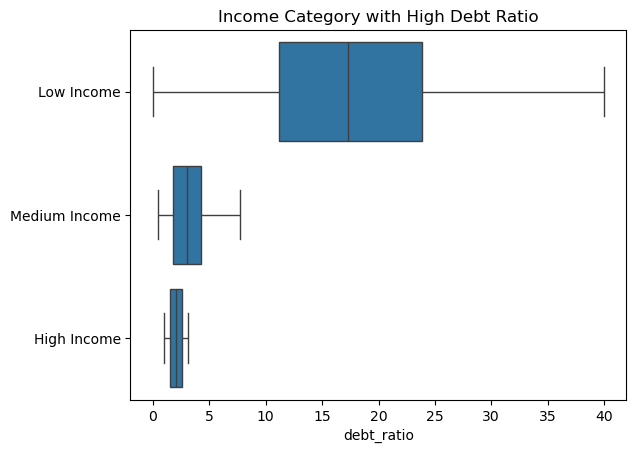

In [21]:
#visualizing category of income with debt
sns.boxplot(y='income_category', x='debt_ratio', data=df)
plt.ylabel('')
plt.title("Income Category with High Debt Ratio")
plt.show()

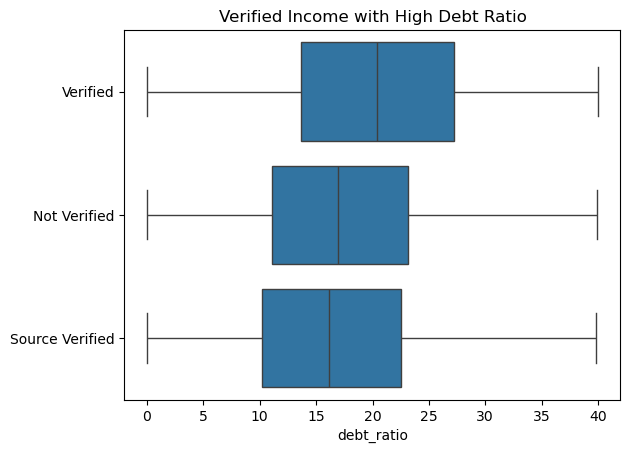

In [22]:
#visualizing verified income with debt
sns.boxplot(y='income_verification', x='debt_ratio', data=df)
plt.title("Verified Income with High Debt Ratio")
plt.ylabel('')
plt.show()

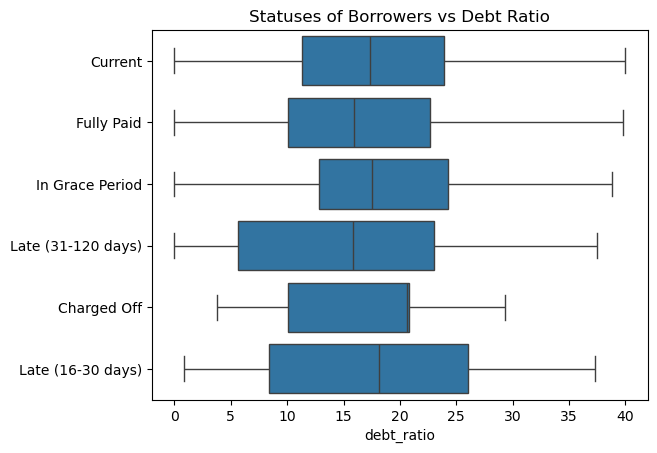

In [23]:
#visualizing loan statuses with debt
sns.boxplot(y='loan_status', x='debt_ratio', data=df)
plt.ylabel('')
plt.title("Statuses of Borrowers vs Debt Ratio")
plt.show()

In [24]:
# checking which loan purposes are riskier
pd.crosstab(df['loan_purpose'], df['income_category'], normalize='index')

income_category,Low Income,Medium Income,High Income
loan_purpose,,,
car,1.000000,0.000000,0.000000
credit_card,1.000000,0.000000,0.000000
debt_consolidation,0.999417,0.000583,0.000000
home_improvement,0.997059,0.002941,0.000000
house,1.000000,0.000000,0.000000
major_purchase,0.990099,0.003300,0.006601
medical,0.993827,0.006173,0.000000
moving,1.000000,0.000000,0.000000
other,0.997812,0.002188,0.000000


## Why they are risky

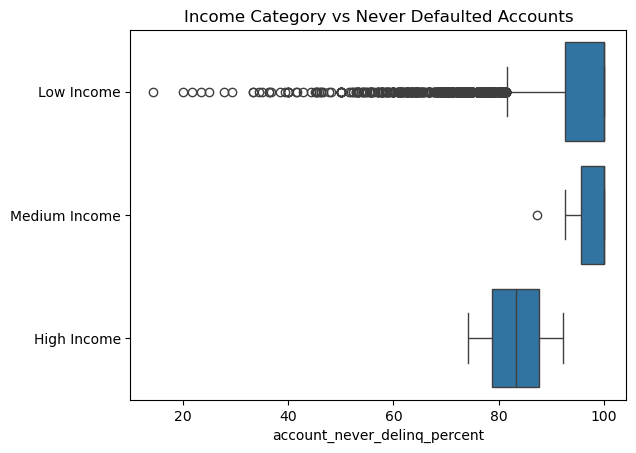

In [25]:
# visualizing which borrowers are less likely to default.
sns.boxplot(y='income_category', x='account_never_delinq_percent', data=df)
plt.title('Income Category vs Never Defaulted Accounts')
plt.ylabel('')
plt.show()

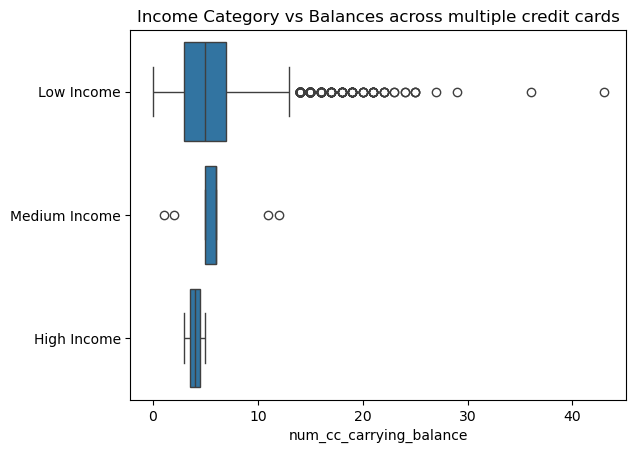

In [26]:
# visualizing how many borrowers carry balances across multiple credit cards.
sns.boxplot(y='income_category', x='num_cc_carrying_balance', data=df)
plt.title('Income Category vs Balances across multiple credit cards')
plt.ylabel('')
plt.show()

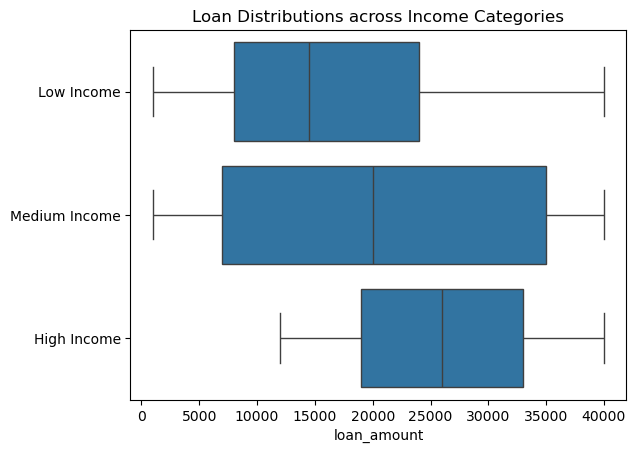

In [27]:
#visualizing loan amount distributions across the income categories
sns.boxplot(y='income_category', x='loan_amount', data=df)
plt.title('Loan Distributions across Income Categories')
plt.ylabel('')
plt.show()

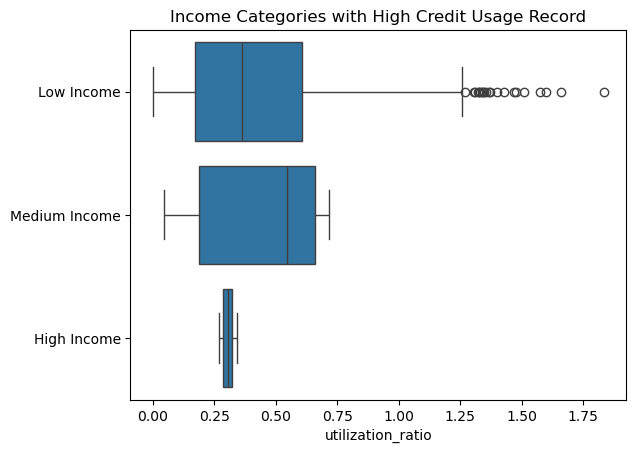

In [28]:
# visualizing whether defaulters more financially stretched
sns.boxplot(y='income_category', x='utilization_ratio', data=df)
plt.title('Income Categories with High Credit Usage Record')
plt.ylabel('')
plt.show()

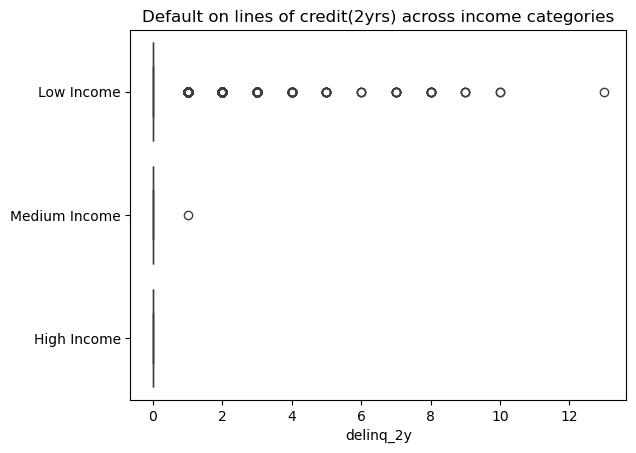

In [29]:
# visualizing whether people with past delinquencies default more.
sns.boxplot(y='income_category', x='delinq_2y', data=df)
plt.title('Default on lines of credit(2yrs) across income categories')
plt.ylabel('')
plt.show()

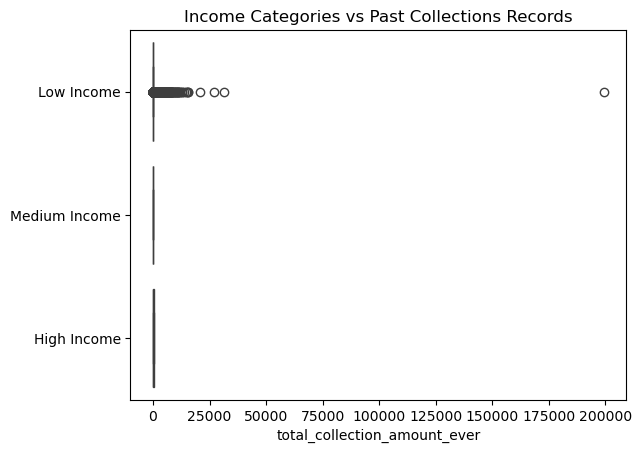

In [30]:
# visualizing borrowers with past collections.
sns.boxplot(y='income_category', x='total_collection_amount_ever', data=df)
plt.title('Income Categories vs Past Collections Records')
plt.ylabel('')
plt.show()

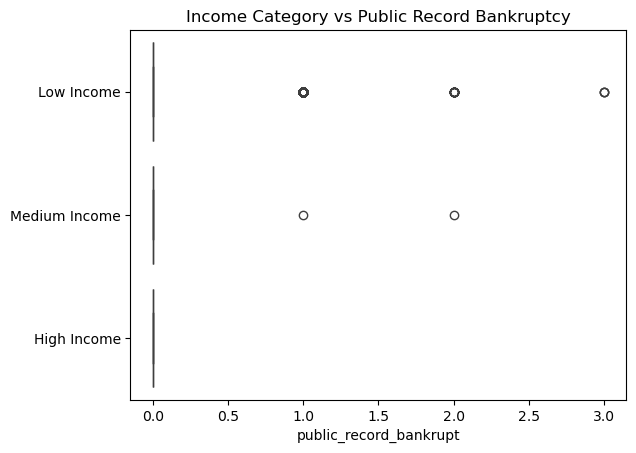

In [31]:
# visualizing borrowers with history of bankruptcy.
sns.boxplot(y='income_category', x='public_record_bankrupt', data=df)
plt.title('Income Category vs Public Record Bankruptcy')
plt.ylabel('')
plt.show()

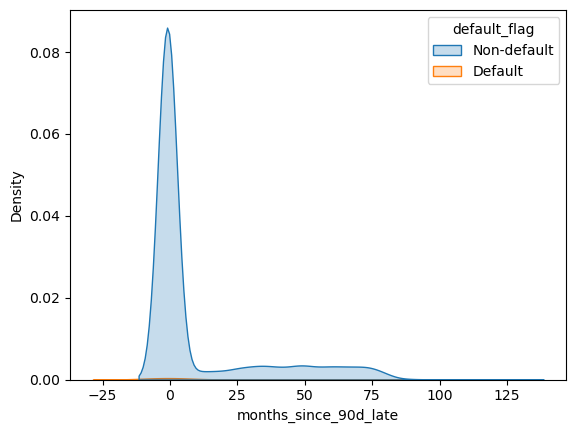

In [32]:
# visualizing distribution plot of delayed payments over 90 days
sns.kdeplot(data=df, x='months_since_90d_late', hue='default_flag', fill=True)
plt.show()

## What to do

- Consider the collections patterns and past delinquencies to score borrowers.
- Use score to compute interest.

In [33]:
# Consider defaulted records. Check distributions flagged
df['default_flag'].value_counts(normalize=True)

default_flag
Non-default    0.988825
Default        0.011175
Name: proportion, dtype: float64

In [34]:
# dropping some columns
df_use = new_df.drop(['emp_title', 'emp_length', 'state', 'homeownership', 'debt_to_income', 'debt_to_income_joint', 'annual_income',
                      'annual_income_joint', 'total_credit_utilized', 'total_credit_limit', 'total_credit_lines', 'income_category',
                  'interest_rate', 'installment', 'grade', 'sub_grade', 'disbursement_method', 'verification_income_joint', 'verified_income',
                  'earliest_credit_line', 'issue_year', 'issue_month', 'issue_date', 'loan_status', 'income_verification', 'total_income',
                  'initial_listing_status','balance', 'paid_total', 'paid_principal', 'paid_interest', 'paid_late_fees'], axis=1)
df_use.head()

,delinq_2y,months_since_last_delinq,inquiries_last_12m,open_credit_lines,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,...,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,credit_age,default_flag,debt_ratio,utilization_ratio,income_per_credit_line
0,0,38.0,6,10,0,0,38.0,0,1250,2,...,0,moving,individual,28000,60,17,Non-default,18.01,0.547595,3214.285714
1,0,-1.0,1,14,0,1,-1.0,0,0,0,...,1,debt_consolidation,individual,5000,36,22,Non-default,5.04,0.150035,1333.333333
2,0,28.0,4,10,0,0,28.0,0,432,1,...,0,other,individual,2000,36,12,Non-default,21.15,0.661348,1290.322581
3,0,-1.0,0,4,0,1,-1.0,0,0,1,...,0,debt_consolidation,individual,21600,36,11,Non-default,10.16,0.196732,7500.000000
4,0,-1.0,7,16,0,0,-1.0,0,0,1,...,0,credit_card,joint,23000,36,10,Non-default,37.66,0.754908,2590.909091


##### Selecting features for our objectives.

In [35]:
# creating encode and select features functions
def encode_features(df):
    # encoding variables
    df_dummies = pd.get_dummies(df, drop_first= True, dtype='int')

    # making sure all columns have no spaces and hyphens between them
    df_dummies.columns = [col.replace(" ","_") for col in df_dummies.columns]
    df_dummies.columns = [col.replace("-","_") for col in df_dummies.columns]
    
    return df_dummies


def select_features(df_dummy):
    """
    Accepts dummy dataframe as inputs.

    Finds the correlation of the dummy variables

    """
    corr = df_dummy.corr()
    corrs = corr['default_flag_Non_default'].sort_values(ascending=False)

    #using pearson regression to select features with p_val less than 0.05
    # building a dictionary of correlation coefficients and their p-values
    dict_of_coeff_and_pvals = {}
    
    column_titles = [col for col in corrs.index if col!= 'default_flag_Non_default']

    # iterating through columns in variable corrs 
    for col in column_titles:
        p_val = pearsonr(df_dummy[col], df_dummy['default_flag_Non_default'])[1]
        dict_of_coeff_and_pvals[col] = {'Correlation_Coefficient':corrs[col],
                        'P_Value':p_val}
        
    dict_of_coeff_and_pvals = pd.DataFrame(dict_of_coeff_and_pvals).T
    dict_of_coeff_and_pvals = dict_of_coeff_and_pvals.sort_values('P_Value')
    df_of_coeff_and_pvals = dict_of_coeff_and_pvals[dict_of_coeff_and_pvals['P_Value']<0.05]
    
    return df_of_coeff_and_pvals

In [36]:
# get encoded df and features selected
df_encoded = encode_features(df_use)
selected_features = select_features(df_encoded)
selected_features

,Correlation_Coefficient,P_Value
income_per_credit_line,-0.061729,6.492557e-10
loan_purpose_house,-0.045348,5.719037e-06
loan_purpose_credit_card,0.029041,3.680329e-03
inquiries_last_12m,-0.026515,8.010924e-03
term,-0.026440,8.190279e-03
num_total_cc_accounts,0.026157,8.901250e-03
months_since_last_credit_inquiry,0.026049,9.187639e-03
num_open_cc_accounts,0.024187,1.557407e-02
open_credit_lines,0.022682,2.331944e-02
num_satisfactory_accounts,0.022661,2.344342e-02


In [38]:
# subsetting only the selected features
dfm = df_encoded[selected_features.index]

dfm.head()

,income_per_credit_line,loan_purpose_house,loan_purpose_credit_card,inquiries_last_12m,term,num_total_cc_accounts,months_since_last_credit_inquiry,num_open_cc_accounts,open_credit_lines,num_satisfactory_accounts,loan_amount,application_type_joint
0,3214.285714,0,0,6,60,14,5.0,8,10,10,28000,0
1,1333.333333,0,0,1,36,24,8.0,14,14,14,5000,0
2,1290.322581,0,0,4,36,14,7.0,8,10,10,2000,0
3,7500.000000,0,0,0,36,3,15.0,3,4,4,21600,0
4,2590.909091,0,1,7,36,20,4.0,15,16,16,23000,1


In [39]:
# defining transformation function
def transform_train_predict(X, y, model):
    """
    Accepts X, y and model as inputs and splits sets into train and test sets.
    Transforms X with StandardScaler.

    Trains model with transformed X_train.
    Predicts outcome with transformed X_test.
    
    Returns a DataFrame of y_test and y_predicted values.
    """
    # splitting data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # transforming X
    scaler = StandardScaler()
    X_train_transformed = scaler.fit_transform(X_train)
    X_test_transformed = scaler.transform(X_test)

    #instantiate model
    model = model
    model.fit(X_train_transformed, y_train)

    #predict y
    y_pred = model.predict(X_test_transformed)

    #creating a dataframe of predicted y values and tested y values
    pred_df = pd.DataFrame({'Y_tested': y_test, 'Y_predicted': y_pred})

    return pred_df

In [40]:
# assigning X and y values
X = dfm
y = dfm_copy['default_flag_Non_default']
model = LogisticRegression()

# show df with predicted values
prediction_df = transform_train_predict(X, y, model)
prediction_df

,Y_tested,Y_predicted
6252,1,1
4684,1,1
1731,1,1
4742,1,1
4521,1,1
...,...,...
6412,1,1
8285,1,1
7853,1,1
1095,1,1


In [41]:
#printing report
from sklearn.metrics import classification_report
print(classification_report(prediction_df['Y_tested'], prediction_df['Y_predicted']))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        38
           1       0.98      1.00      0.99      1962

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000



## Transferring Model

In [ ]:
# preparing to transfer model
import pickle

#saving X as csv
X_file = X.to_csv('x.csv', index=False)

# saving the trained model
filename = 'trained_model.sav'
pickle.dump(model, open(filename, 'wb'))

#loading model which was saved
loaded_model = pickle.load(open('trained_model.sav', 'rb'))

input_df = pd.read_csv("C:/Users/naaod/Downloads/loan_payback_analysis/Credit-Risk-Decision-System/x.csv")
# assigning X
input_data = input_df.values

# making predictions
prediction = loaded_model.predict(input_data)
prediction

array([0, 0, 0, ..., 0, 0, 0])